# 05 - Evaluation: Comparative Model Assessment

**DSR Pipeline Phase: Evaluation & Deployment Recommendation**

This notebook performs the full comparative evaluation of all 4 unsupervised
anomaly detection models using:
- **Intrinsic metrics:** Silhouette, Davies-Bouldin, Calinski-Harabasz (cluster quality)
- **Extrinsic metrics:** Accuracy, Sensitivity, Specificity, F1, AUC-ROC (vs AAMI ground truth)
- **Efficiency metrics:** Training time, peak memory usage

The `ModelComparator` runs all models and produces a unified comparison table.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from ecg_anomaly.config import SystemConfig
from ecg_anomaly.data.loader import MITBIHLoader
from ecg_anomaly.preprocessing.pipeline import PreprocessingPipeline
from ecg_anomaly.features.signal_pca import SignalPCAExtractor
from ecg_anomaly.evaluation.comparator import ModelComparator
from ecg_anomaly.evaluation.extrinsic import evaluate_extrinsic
from ecg_anomaly.evaluation.intrinsic import evaluate_intrinsic
from ecg_anomaly.visualization.reports import plot_metrics_comparison, plot_confusion_matrices
from ecg_anomaly.visualization.clusters import plot_pca_scatter

sns.set_style("whitegrid")
config = SystemConfig.from_yaml("../config/default.yaml")
config.setup_logging()

## 1. Prepare Data (Full Pipeline)

In [2]:
loader = MITBIHLoader(config)
dataset = loader.load(config.dataset_path)

pipeline = PreprocessingPipeline(config)
preprocessed = pipeline.run(dataset)

pca_extractor = SignalPCAExtractor(variance_threshold=config.pca_variance_threshold)
X_clustering = pca_extractor.fit_transform(preprocessed.segments)
X_autoencoder = pca_extractor.get_raw_for_autoencoder(preprocessed.segments)
true_labels = preprocessed.labels

print(f"Dataset: {preprocessed.metadata['n_beats']:,} beats from {preprocessed.metadata['n_records']} records")
print(f"Clustering features (PCA): {X_clustering.shape}")
print(f"Autoencoder features (raw): {X_autoencoder.shape}")
print(f"Class distribution: Normal={int(np.sum(true_labels==0)):,}, Anomalous={int(np.sum(true_labels==1)):,}")

00:45:03 [ecg_anomaly.data.loader] INFO: Cargados 44 registros: 100733 latidos (90125 normal, 10608 anomalo)
00:45:04 [ecg_anomaly.preprocessing.pipeline] INFO: Preprocesamiento completo: 100705 latidos [100705, 200] (normal=90099, anomalo=10606)
00:45:05 [ecg_anomaly.features.signal_pca] INFO: PCA: 200 -> 12 componentes (95.3% varianza retenida)


Dataset: 100,705 beats from 44 records
Clustering features (PCA): (100705, 12)
Autoencoder features (raw): (100705, 200)
Class distribution: Normal=90,099, Anomalous=10,606


## 2. Run Comparative Evaluation

The `ModelComparator` trains each model, measures efficiency, and computes
all intrinsic and extrinsic metrics in one pass.

In [3]:
comparator = ModelComparator(config)
results_df = comparator.run_all(X_clustering, X_autoencoder, true_labels)

print("\nComparative evaluation complete.")
print(f"Models evaluated: {len(comparator.results)}")

00:45:05 [ecg_anomaly.evaluation.comparator] INFO: Evaluando kmeans...
00:47:55 [ecg_anomaly.evaluation.comparator] INFO: kmeans completado: F1=0.177, Silhouette=0.256, Tiempo=2.88s
00:47:55 [ecg_anomaly.evaluation.comparator] INFO: Evaluando dbscan...
00:48:05 [ecg_anomaly.models.dbscan] INFO: DBSCAN eps auto-optimizado: 3.9164
00:51:33 [ecg_anomaly.evaluation.comparator] INFO: dbscan completado: F1=0.238, Silhouette=0.008, Tiempo=63.53s
00:51:33 [ecg_anomaly.evaluation.comparator] INFO: Evaluando hdbscan...
00:54:05 [ecg_anomaly.models.hdbscan_model] INFO: HDBSCAN: 107 clusters, 21385 ruido (21.2%)
00:55:50 [ecg_anomaly.evaluation.comparator] INFO: hdbscan completado: F1=0.235, Silhouette=0.487, Tiempo=151.36s
00:55:50 [ecg_anomaly.evaluation.comparator] INFO: Evaluando autoencoder...
I0000 00:00:1778565357.524041   14831 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778565410.323611   14831 cudart_stub.cc:31] Could not find cuda d


Comparative evaluation complete.
Models evaluated: 4


## 3. Comparison Table

In [4]:
# Display the full comparison table
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
display(results_df.round(4))

,Modelo,Silhouette,Davies-Bouldin,Calinski-Harabasz,Accuracy,Sensitivity,Specificity,F1,AUC-ROC,Tiempo (s),Memoria (MB),Anomalias
0,kmeans,0.2561,1.4726,38848.1071,0.5106,0.4993,0.5119,0.1769,0.5056,2.8806,18.51,49269
1,dbscan,0.0084,0.8608,1391.1863,0.8656,0.1996,0.9440,0.2382,0.5718,63.5285,38.35,7167
2,hdbscan,0.4869,0.7563,13092.5201,0.7570,0.3543,0.8044,0.2349,0.5793,151.3630,32.39,21385
3,autoencoder,NaN,NaN,NaN,0.8640,0.0918,0.9549,0.1245,0.5234,194.5835,393.47,5036


In [5]:
# Highlight key metrics
key_metrics = ["Modelo", "Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC", "Silhouette", "Tiempo (s)"]
available = [c for c in key_metrics if c in results_df.columns]
display(results_df[available].round(4))

,Modelo,Accuracy,Sensitivity,Specificity,F1,AUC-ROC,Silhouette,Tiempo (s)
0,kmeans,0.5106,0.4993,0.5119,0.1769,0.5056,0.2561,2.8806
1,dbscan,0.8656,0.1996,0.9440,0.2382,0.5718,0.0084,63.5285
2,hdbscan,0.7570,0.3543,0.8044,0.2349,0.5793,0.4869,151.3630
3,autoencoder,0.8640,0.0918,0.9549,0.1245,0.5234,NaN,194.5835


## 4. Metrics Comparison Charts

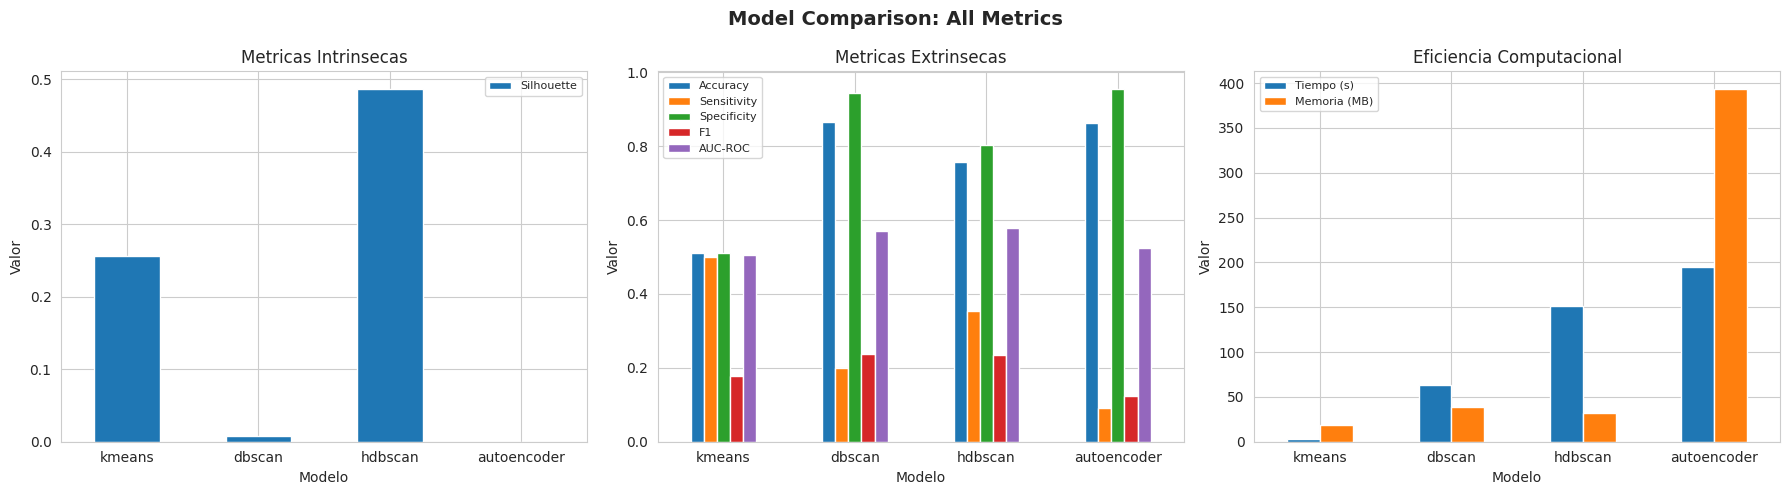

In [6]:
plot_metrics_comparison(results_df, title="Model Comparison: All Metrics")

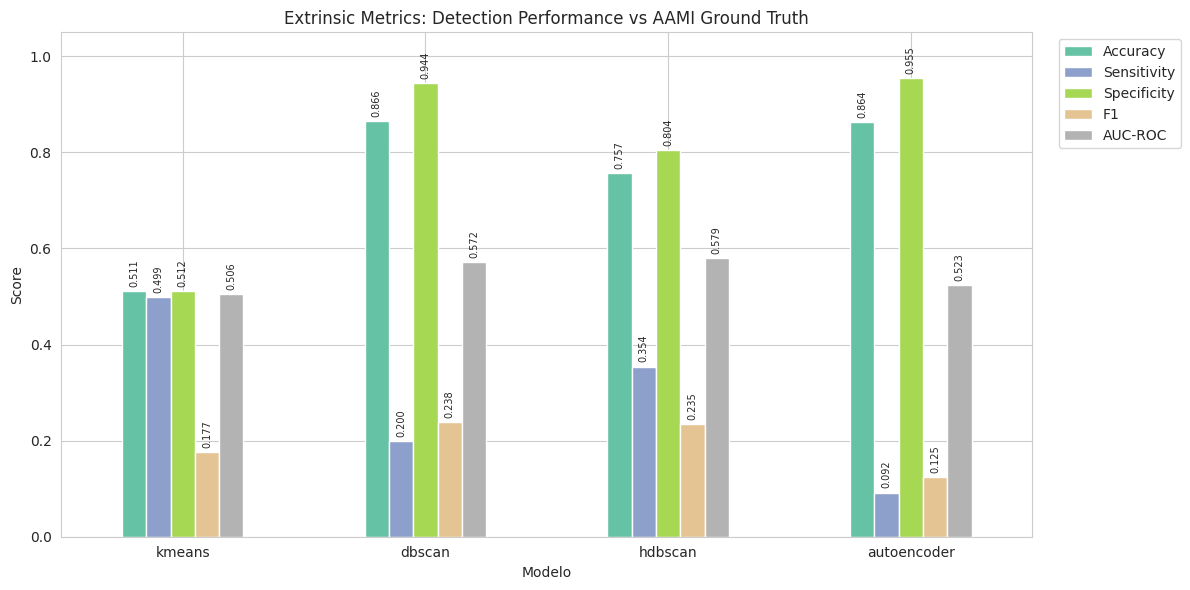

In [7]:
# Focused extrinsic metrics bar chart
extrinsic_cols = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC"]
available_ext = [c for c in extrinsic_cols if c in results_df.columns]

if available_ext:
    plot_data = results_df[["Modelo"] + available_ext].set_index("Modelo")
    plot_data = plot_data.apply(pd.to_numeric, errors="coerce")

    fig, ax = plt.subplots(figsize=(12, 6))
    plot_data.plot(kind="bar", ax=ax, rot=0, colormap="Set2")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_title("Extrinsic Metrics: Detection Performance vs AAMI Ground Truth")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    # Add value labels
    for container in ax.containers:
        ax.bar_label(container, fmt="%.3f", fontsize=7, rotation=90, padding=3)

    plt.tight_layout()
    plt.show()

## 5. Confusion Matrices

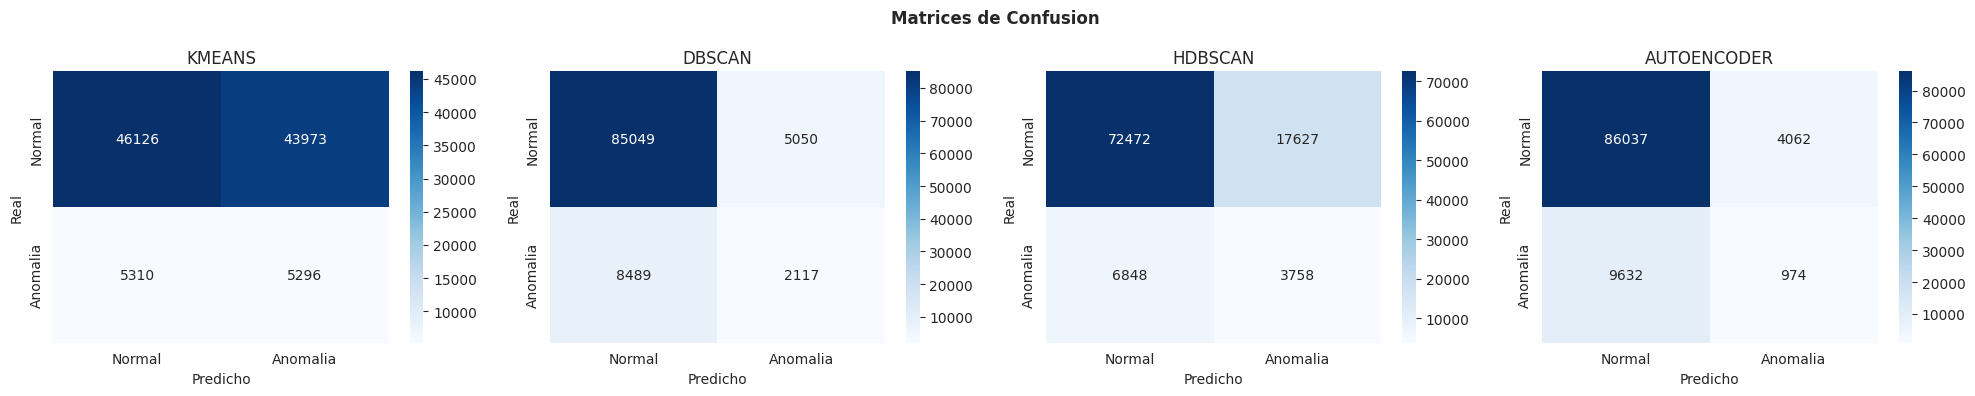

In [8]:
plot_confusion_matrices(comparator.results)

In [9]:
# Detailed confusion matrix breakdown
for result in comparator.results:
    model = result["model"]
    tp = result.get("extrinsic_true_positives", 0)
    fp = result.get("extrinsic_false_positives", 0)
    tn = result.get("extrinsic_true_negatives", 0)
    fn = result.get("extrinsic_false_negatives", 0)
    print(f"\n{model.upper()}:")
    print(f"  True Positives (correct anomalies):  {tp:,}")
    print(f"  False Positives (false alarms):      {fp:,}")
    print(f"  True Negatives (correct normals):    {tn:,}")
    print(f"  False Negatives (missed anomalies):  {fn:,}")


KMEANS:
  True Positives (correct anomalies):  5,296
  False Positives (false alarms):      43,973
  True Negatives (correct normals):    46,126
  False Negatives (missed anomalies):  5,310

DBSCAN:
  True Positives (correct anomalies):  2,117
  False Positives (false alarms):      5,050
  True Negatives (correct normals):    85,049
  False Negatives (missed anomalies):  8,489

HDBSCAN:
  True Positives (correct anomalies):  3,758
  False Positives (false alarms):      17,627
  True Negatives (correct normals):    72,472
  False Negatives (missed anomalies):  6,848

AUTOENCODER:
  True Positives (correct anomalies):  974
  False Positives (false alarms):      4,062
  True Negatives (correct normals):    86,037
  False Negatives (missed anomalies):  9,632


## 6. PCA Scatter: Ground Truth vs Predictions

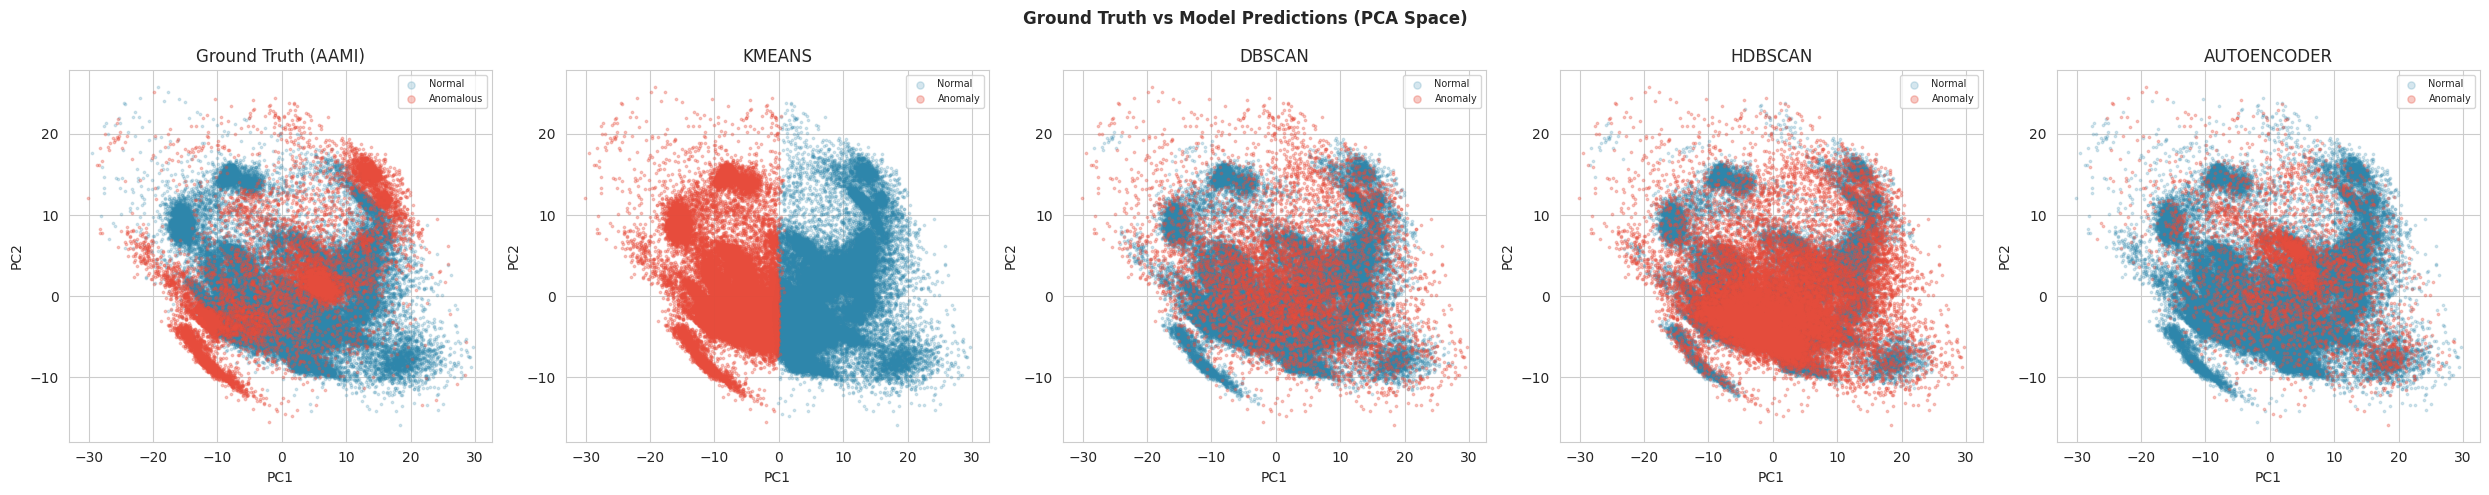

In [10]:
fig, axes = plt.subplots(1, len(config.models) + 1, figsize=(5 * (len(config.models) + 1), 5))

# Ground truth
normal_mask = true_labels == 0
anomaly_mask = true_labels == 1
axes[0].scatter(X_clustering[normal_mask, 0], X_clustering[normal_mask, 1],
               alpha=0.2, s=3, c="#2E86AB", label="Normal")
axes[0].scatter(X_clustering[anomaly_mask, 0], X_clustering[anomaly_mask, 1],
               alpha=0.3, s=3, c="#E74C3C", label="Anomalous")
axes[0].set_title("Ground Truth (AAMI)")
axes[0].legend(fontsize=7, markerscale=3)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Each model's predictions
for i, model_name in enumerate(config.models):
    detector = comparator.detectors[i]
    if detector.anomaly_labels_ is not None:
        pred_normal = detector.anomaly_labels_ == 0
        pred_anomaly = detector.anomaly_labels_ == 1
        axes[i+1].scatter(X_clustering[pred_normal, 0], X_clustering[pred_normal, 1],
                         alpha=0.2, s=3, c="#2E86AB", label="Normal")
        axes[i+1].scatter(X_clustering[pred_anomaly, 0], X_clustering[pred_anomaly, 1],
                         alpha=0.3, s=3, c="#E74C3C", label="Anomaly")
        axes[i+1].legend(fontsize=7, markerscale=3)
    axes[i+1].set_title(f"{model_name.upper()}")
    axes[i+1].set_xlabel("PC1")
    axes[i+1].set_ylabel("PC2")

plt.suptitle("Ground Truth vs Model Predictions (PCA Space)", fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Efficiency Comparison

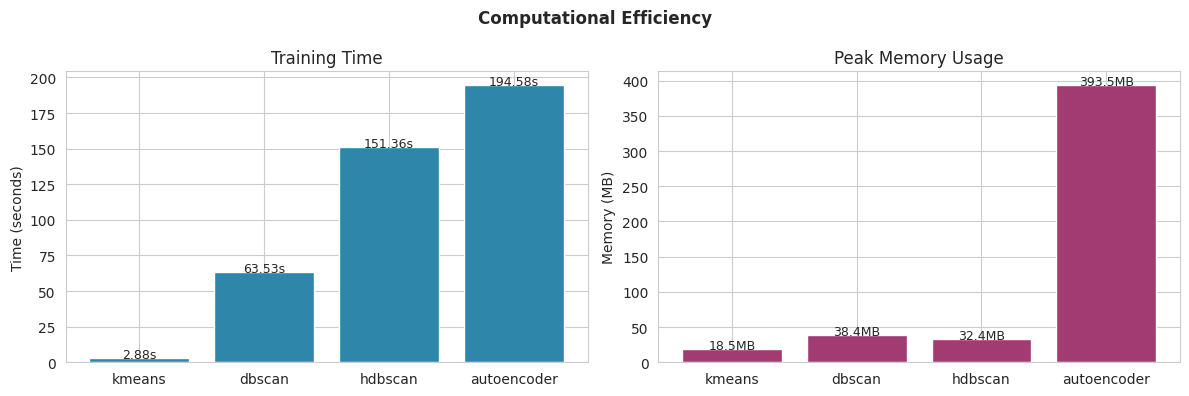

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = [r["model"] for r in comparator.results]
times = [r.get("efficiency_time_seconds", 0) for r in comparator.results]
memory = [r.get("efficiency_peak_memory_mb", 0) for r in comparator.results]

axes[0].bar(models, times, color="#2E86AB")
axes[0].set_ylabel("Time (seconds)")
axes[0].set_title("Training Time")
for i, v in enumerate(times):
    axes[0].text(i, v + 0.01, f"{v:.2f}s", ha="center", fontsize=9)

axes[1].bar(models, memory, color="#A23B72")
axes[1].set_ylabel("Memory (MB)")
axes[1].set_title("Peak Memory Usage")
for i, v in enumerate(memory):
    axes[1].text(i, v + 0.01, f"{v:.1f}MB", ha="center", fontsize=9)

plt.suptitle("Computational Efficiency", fontweight="bold")
plt.tight_layout()
plt.show()

## 8. Best Model Selection

In [12]:
# Determine best model by F1 score
best_f1 = comparator.get_best_model(metric="extrinsic_f1")
best_acc = comparator.get_best_model(metric="extrinsic_accuracy")
best_sens = comparator.get_best_model(metric="extrinsic_sensitivity")
best_time = comparator.get_best_model(metric="efficiency_time_seconds")

print("Best model by metric:")
print(f"  F1 Score:    {best_f1}")
print(f"  Accuracy:    {best_acc}")
print(f"  Sensitivity: {best_sens}")
print(f"  Speed:       {best_time}")
print()
print(f"Overall recommendation (by F1): {best_f1}")

Best model by metric:
  F1 Score:    dbscan
  Accuracy:    dbscan
  Sensitivity: kmeans
  Speed:       kmeans

Overall recommendation (by F1): dbscan


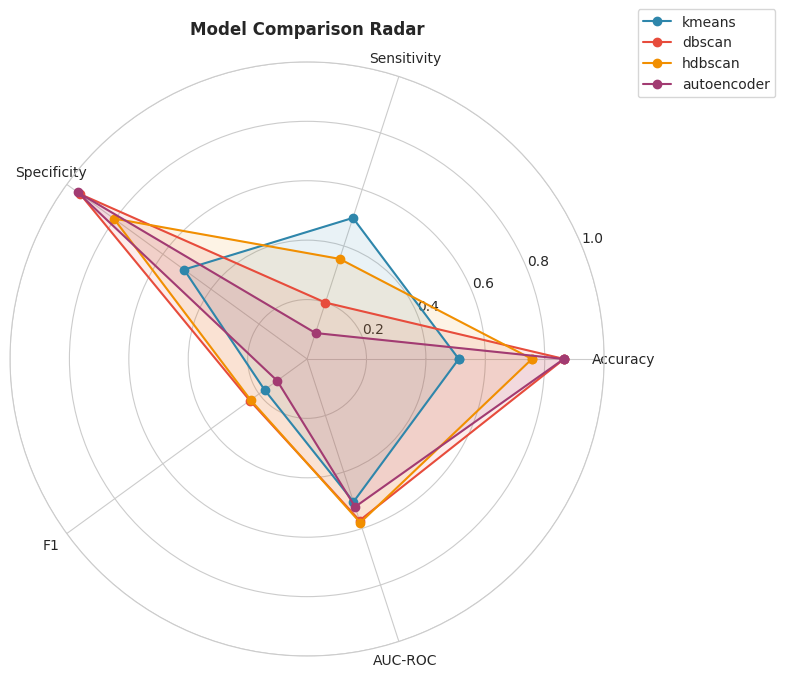

In [13]:
# Radar chart for multi-metric comparison
radar_metrics = ["Accuracy", "Sensitivity", "Specificity", "F1", "AUC-ROC"]
available_radar = [m for m in radar_metrics if m in results_df.columns]

if len(available_radar) >= 3:
    from matplotlib.patches import FancyBboxPatch
    angles = np.linspace(0, 2 * np.pi, len(available_radar), endpoint=False).tolist()
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    colors = ["#2E86AB", "#E74C3C", "#F18F01", "#A23B72"]

    for i, row in results_df.iterrows():
        values = [float(row[m]) if pd.notna(row[m]) else 0 for m in available_radar]
        values += values[:1]
        ax.plot(angles, values, "o-", linewidth=1.5, label=row["Modelo"],
                color=colors[i % len(colors)])
        ax.fill(angles, values, alpha=0.1, color=colors[i % len(colors)])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(available_radar)
    ax.set_ylim(0, 1)
    ax.set_title("Model Comparison Radar", pad=20, fontweight="bold")
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()

## Summary

### Key Findings

The comparative evaluation assessed 4 unsupervised methods for ECG anomaly detection:

| Method | Approach | Strengths |
|---|---|---|
| KMeans | Partition-based (k=2) | Fast, simple baseline |
| DBSCAN | Density-based | No k required, finds noise |
| HDBSCAN | Hierarchical density | Handles varying densities |
| Autoencoder | Reconstruction error | Learns complex patterns |

### Evaluation Framework
- **Intrinsic metrics** assess cluster quality without labels
- **Extrinsic metrics** compare against AAMI clinical annotations
- **Efficiency metrics** measure computational cost

The best model overall (by F1 score) balances sensitivity (detecting real anomalies)
with specificity (avoiding false alarms) -- critical for clinical ECG screening.